# 02 — Pre-processing & EDA

**Project**: YOLOv11s Person Detection  
**Tujuan**: Analisis data, split 70/15/15, konversi COCO → YOLO format

---

## 2.1 Import Libraries & Load Konfigurasi

In [14]:
import os
import json
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from collections import Counter

sns.set_theme(style='whitegrid')

# Load konfigurasi dari notebook 01
with open('data/acquisition_config.json') as f:
    cfg = json.load(f)

ANNOT_FILE     = Path(cfg['annot_file'])
RAW_IMAGES_DIR = Path(cfg['raw_images_dir'])
TARGET_CLASS   = cfg['target_class']
RANDOM_SEED    = cfg['random_seed']

# Koreksi path: fiftyone mengekspor gambar ke <raw_dir>/data/, bukan images/
if not RAW_IMAGES_DIR.exists() or not any(RAW_IMAGES_DIR.glob('*')):
    alt = RAW_IMAGES_DIR.parent / 'data'
    if alt.exists() and any(alt.glob('*')):
        RAW_IMAGES_DIR = alt
        print(f'  [INFO] RAW_IMAGES_DIR dikoreksi -> {RAW_IMAGES_DIR}')

# Koreksi path anotasi: fiftyone menyimpan labels.json di <raw_dir>/
if not ANNOT_FILE.exists():
    alt_annot = ANNOT_FILE.parent.parent / 'labels.json'
    if alt_annot.exists():
        ANNOT_FILE = alt_annot
        print(f'  [INFO] ANNOT_FILE dikoreksi -> {ANNOT_FILE}')

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Konfigurasi berhasil di-load')
print(f'  File anotasi : {ANNOT_FILE}')
print(f'  Direktori img: {RAW_IMAGES_DIR}')
print(f'  Target class : {TARGET_CLASS}')


  [INFO] RAW_IMAGES_DIR dikoreksi -> data\raw\data
Konfigurasi berhasil di-load
  File anotasi : data\raw\labels.json
  Direktori img: data\raw\data
  Target class : person


## 2.2 Load Data Anotasi COCO

In [15]:
with open(ANNOT_FILE) as f:
    coco = json.load(f)

images      = {img['id']: img for img in coco['images']}
annotations = coco['annotations']
categories  = {cat['id']: cat['name'] for cat in coco['categories']}

# Buat DataFrame anotasi
rows = []
for ann in annotations:
    img_info = images[ann['image_id']]
    x, y, w, h = ann['bbox']
    img_w = img_info['width']
    img_h = img_info['height']
    rows.append({
        'image_id'    : ann['image_id'],
        'file_name'   : img_info['file_name'],
        'img_width'   : img_w,
        'img_height'  : img_h,
        'bbox_x'      : x,
        'bbox_y'      : y,
        'bbox_w'      : w,
        'bbox_h'      : h,
        'bbox_area'   : w * h,
        'rel_area'    : (w * h) / (img_w * img_h),
        'aspect_ratio': w / h if h > 0 else 0,
        'category'    : categories[ann['category_id']]
    })

df = pd.DataFrame(rows)
print(f'Total anotasi    : {len(df)}')
print(f'Total gambar unik: {df["image_id"].nunique()}')
print(f'\nContoh 5 baris pertama:')
df.head()


Total anotasi    : 12565
Total gambar unik: 3000

Contoh 5 baris pertama:


,image_id,file_name,img_width,img_height,bbox_x,bbox_y,bbox_w,bbox_h,bbox_area,rel_area,aspect_ratio,category
0,1,000000142718.jpg,640,480,431.65,206.74,128.54,249.35,32051.4490,0.104334,0.515500,person
1,1,000000142718.jpg,640,480,365.43,239.58,45.41,110.21,5004.6361,0.016291,0.412032,person
2,1,000000142718.jpg,640,480,356.13,218.99,30.75,80.27,2468.3025,0.008035,0.383082,person
3,1,000000142718.jpg,640,480,406.25,210.30,45.59,87.31,3980.4629,0.012957,0.522162,person
4,1,000000142718.jpg,640,480,312.12,248.18,41.59,95.37,3966.4383,0.012912,0.436091,person


## 2.3 EDA — Exploratory Data Analysis

### 2.3.1 Distribusi Jumlah Person per Gambar

Statistik jumlah person per gambar:
count    3000.000000
mean        4.188333
std         4.253182
min         1.000000
25%         1.000000
50%         2.000000
75%         6.000000
max        14.000000

Gambar dengan 1 person   : 1168 (38.9%)
Gambar dengan 2-5 person : 1045
Gambar dengan > 5 person : 787 (crowd scenes)


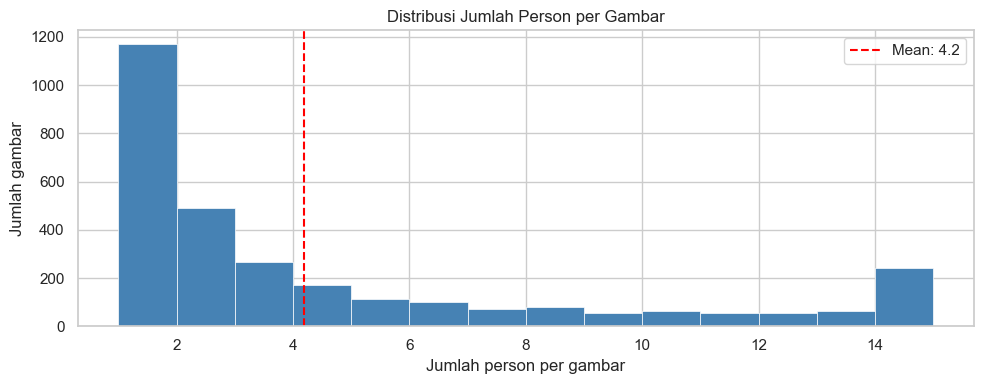

In [16]:
persons_per_image = df.groupby('image_id').size()

print('Statistik jumlah person per gambar:')
print(persons_per_image.describe().to_string())
print(f'\nGambar dengan 1 person   : {(persons_per_image == 1).sum()} ({(persons_per_image == 1).mean()*100:.1f}%)')
print(f'Gambar dengan 2-5 person : {((persons_per_image >= 2) & (persons_per_image <= 5)).sum()}')
print(f'Gambar dengan > 5 person : {(persons_per_image > 5).sum()} (crowd scenes)')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(persons_per_image.values, bins=range(1, min(persons_per_image.max()+2, 30)),
        color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Jumlah person per gambar')
ax.set_ylabel('Jumlah gambar')
ax.set_title('Distribusi Jumlah Person per Gambar')
ax.axvline(persons_per_image.mean(), color='red', linestyle='--', label=f'Mean: {persons_per_image.mean():.1f}')
ax.legend()
plt.tight_layout()
plt.savefig('data/eda_persons_per_image.png', dpi=100)
plt.show()


### 2.3.2 Distribusi Ukuran Bounding Box

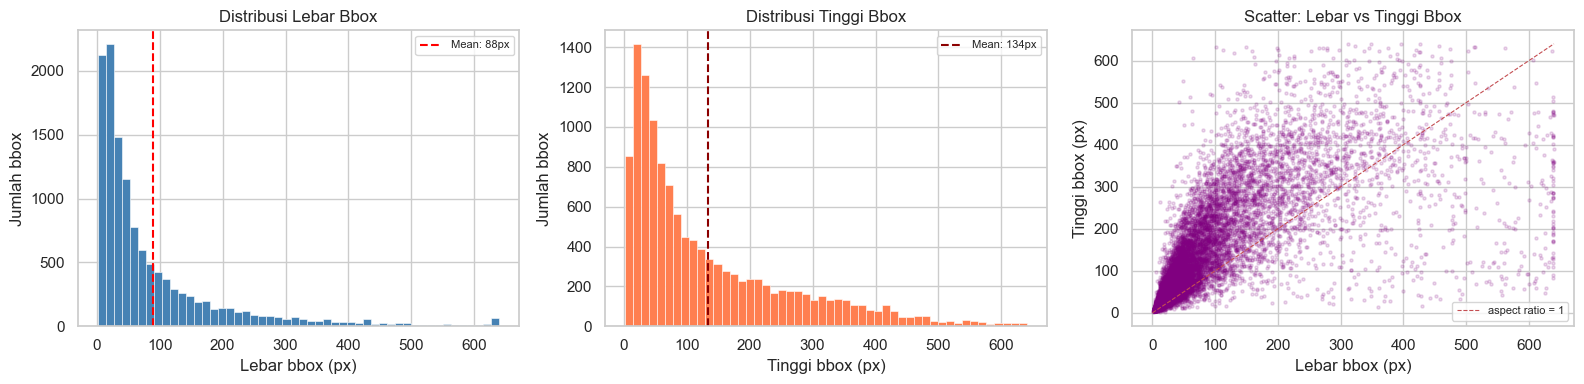


Statistik ukuran bbox:
        bbox_w   bbox_h  bbox_area
count  12565.0  12565.0    12565.0
mean      88.4    134.1    22146.2
std      111.6    129.3    42893.0
min        1.4      2.3        3.8
25%       19.4     36.6      725.1
50%       44.8     82.7     3759.3
75%      109.0    198.2    21329.4
max      640.0    640.0   397658.4

Kategori bbox (berdasarkan COCO standard):
  Kecil  (< 32px)    : 5133 (40.9%)
  Sedang (32-96px)   : 4085 (32.5%)
  Besar  (> 96px)    : 3347 (26.6%)


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['bbox_w'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Lebar bbox (px)')
axes[0].set_ylabel('Jumlah bbox')
axes[0].set_title('Distribusi Lebar Bbox')
axes[0].axvline(df['bbox_w'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["bbox_w"].mean():.0f}px')
axes[0].legend(fontsize=8)

axes[1].hist(df['bbox_h'], bins=50, color='coral', edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('Tinggi bbox (px)')
axes[1].set_ylabel('Jumlah bbox')
axes[1].set_title('Distribusi Tinggi Bbox')
axes[1].axvline(df['bbox_h'].mean(), color='darkred', linestyle='--',
                label=f'Mean: {df["bbox_h"].mean():.0f}px')
axes[1].legend(fontsize=8)

axes[2].scatter(df['bbox_w'], df['bbox_h'], alpha=0.15, s=5, color='purple')
axes[2].set_xlabel('Lebar bbox (px)')
axes[2].set_ylabel('Tinggi bbox (px)')
axes[2].set_title('Scatter: Lebar vs Tinggi Bbox')
axes[2].plot([0, df['bbox_w'].max()], [0, df['bbox_w'].max()],
             'r--', linewidth=0.8, label='aspect ratio = 1')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('data/eda_bbox_size.png', dpi=100)
plt.show()

print('\nStatistik ukuran bbox:')
print(df[['bbox_w', 'bbox_h', 'bbox_area']].describe().round(1).to_string())

small  = (df['bbox_w'] < 32) | (df['bbox_h'] < 32)
medium = (~small) & ((df['bbox_w'] < 96) | (df['bbox_h'] < 96))
large  = ~small & ~medium
print(f'\nKategori bbox (berdasarkan COCO standard):')
print(f'  Kecil  (< 32px)    : {small.sum()} ({small.mean()*100:.1f}%)')
print(f'  Sedang (32-96px)   : {medium.sum()} ({medium.mean()*100:.1f}%)')
print(f'  Besar  (> 96px)    : {large.sum()} ({large.mean()*100:.1f}%)')


### 2.3.3 Distribusi Aspect Ratio Bbox

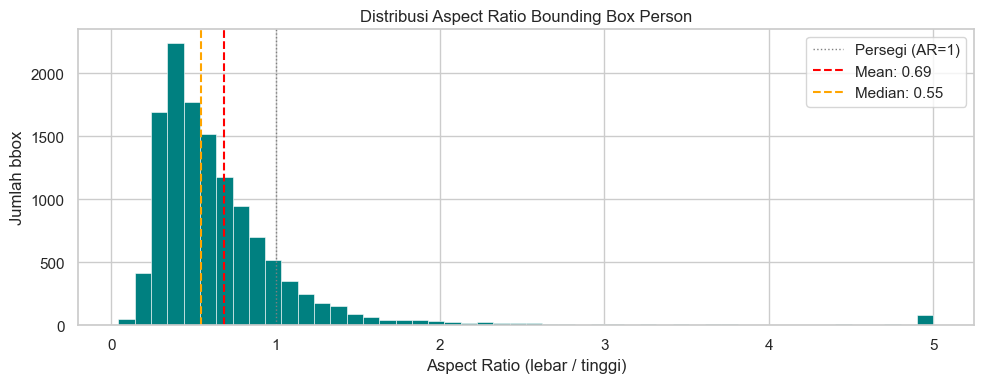

Mayoritas bbox person memiliki aspect ratio < 1 (tinggi > lebar - portrait)
Mean AR  : 0.686
Median AR: 0.546


In [18]:
ar = df['aspect_ratio'].clip(0, 5)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ar, bins=50, color='teal', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Aspect Ratio (lebar / tinggi)')
ax.set_ylabel('Jumlah bbox')
ax.set_title('Distribusi Aspect Ratio Bounding Box Person')
ax.axvline(1.0, color='gray', linestyle=':', linewidth=1, label='Persegi (AR=1)')
ax.axvline(ar.mean(), color='red', linestyle='--', label=f'Mean: {ar.mean():.2f}')
ax.axvline(ar.median(), color='orange', linestyle='--', label=f'Median: {ar.median():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('data/eda_aspect_ratio.png', dpi=100)
plt.show()

print(f'Mayoritas bbox person memiliki aspect ratio < 1 (tinggi > lebar - portrait)')
print(f'Mean AR  : {ar.mean():.3f}')
print(f'Median AR: {ar.median():.3f}')


### 2.3.4 Distribusi Resolusi Gambar

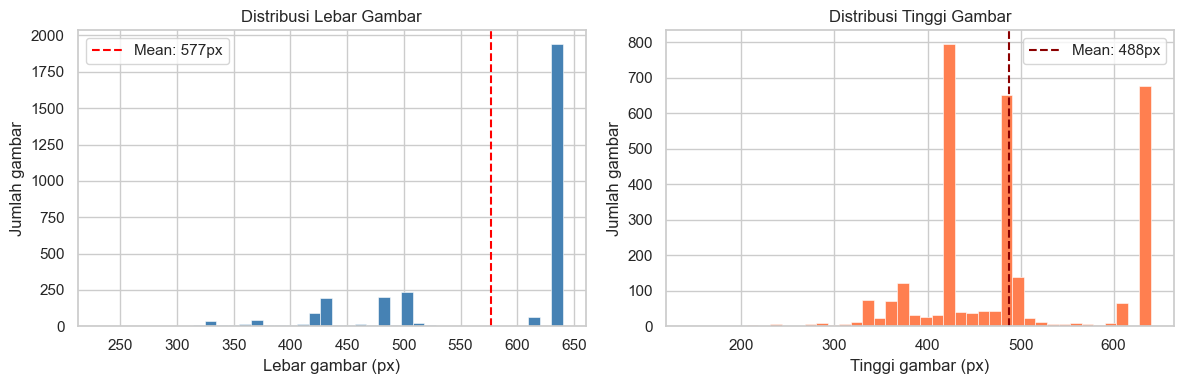

Statistik resolusi gambar:
       img_width  img_height
count     3000.0      3000.0
mean       577.1       488.0
std         93.5        97.5
min        233.0       144.0
25%        500.0       427.0
50%        640.0       480.0
75%        640.0       596.2
max        640.0       640.0


In [19]:
img_sizes = df.drop_duplicates('image_id')[['img_width', 'img_height']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(img_sizes['img_width'], bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Lebar gambar (px)')
axes[0].set_ylabel('Jumlah gambar')
axes[0].set_title('Distribusi Lebar Gambar')
axes[0].axvline(img_sizes['img_width'].mean(), color='red', linestyle='--',
                label=f'Mean: {img_sizes["img_width"].mean():.0f}px')
axes[0].legend()

axes[1].hist(img_sizes['img_height'], bins=40, color='coral', edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('Tinggi gambar (px)')
axes[1].set_ylabel('Jumlah gambar')
axes[1].set_title('Distribusi Tinggi Gambar')
axes[1].axvline(img_sizes['img_height'].mean(), color='darkred', linestyle='--',
                label=f'Mean: {img_sizes["img_height"].mean():.0f}px')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/eda_image_resolution.png', dpi=100)
plt.show()

print('Statistik resolusi gambar:')
print(img_sizes.describe().round(1).to_string())


### 2.3.5 Area Bbox Relatif terhadap Gambar

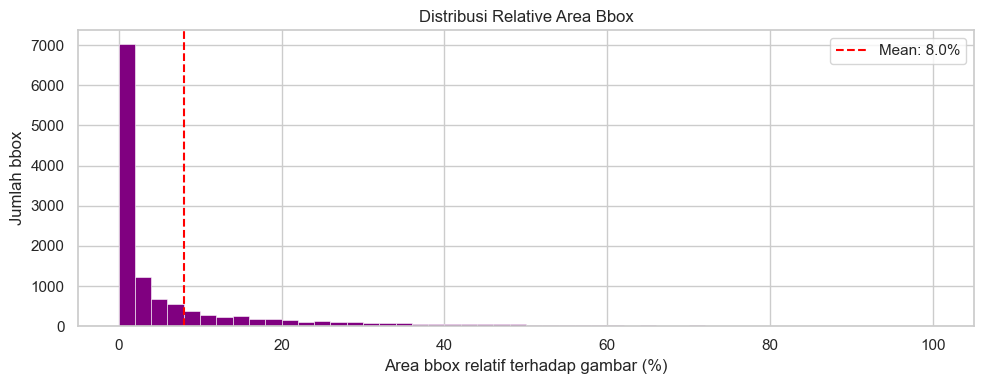

Bbox sangat kecil (< 1% area gambar) : 5679 (45.2%)
Bbox kecil-sedang (1-10%)            : 4173 (33.2%)
Bbox besar (> 10%)                   : 2713 (21.6%)


In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['rel_area'] * 100, bins=50, color='purple', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Area bbox relatif terhadap gambar (%)')
ax.set_ylabel('Jumlah bbox')
ax.set_title('Distribusi Relative Area Bbox')
ax.axvline(df['rel_area'].mean() * 100, color='red', linestyle='--',
           label=f'Mean: {df["rel_area"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig('data/eda_rel_area.png', dpi=100)
plt.show()

tiny  = (df['rel_area'] < 0.01).sum()
small = ((df['rel_area'] >= 0.01) & (df['rel_area'] < 0.1)).sum()
large = (df['rel_area'] >= 0.1).sum()

print(f'Bbox sangat kecil (< 1% area gambar) : {tiny} ({tiny/len(df)*100:.1f}%)')
print(f'Bbox kecil-sedang (1-10%)            : {small} ({small/len(df)*100:.1f}%)')
print(f'Bbox besar (> 10%)                   : {large} ({large/len(df)*100:.1f}%)')


### 2.3.6 Ringkasan EDA

In [21]:
total_images = df['image_id'].nunique()
total_annot  = len(df)

print('=' * 50)
print('           RINGKASAN EDA')
print('=' * 50)
print(f'Total gambar unik    : {total_images}')
print(f'Total anotasi        : {total_annot}')
print(f'Avg person/gambar    : {total_annot/total_images:.2f}')
print(f'Avg bbox width       : {df["bbox_w"].mean():.1f} px')
print(f'Avg bbox height      : {df["bbox_h"].mean():.1f} px')
print(f'Median aspect ratio  : {df["aspect_ratio"].median():.3f}')
print(f'Avg img resolution   : {img_sizes["img_width"].mean():.0f}x{img_sizes["img_height"].mean():.0f} px')
print('=' * 50)


           RINGKASAN EDA
Total gambar unik    : 3000
Total anotasi        : 12565
Avg person/gambar    : 4.19
Avg bbox width       : 88.4 px
Avg bbox height      : 134.1 px
Median aspect ratio  : 0.546
Avg img resolution   : 577x488 px


## 2.4 Split Data: 70 / 15 / 15

In [22]:
from sklearn.model_selection import train_test_split

all_image_ids = df['image_id'].unique().tolist()
random.shuffle(all_image_ids)

train_ids, temp_ids = train_test_split(
    all_image_ids, test_size=0.30, random_state=RANDOM_SEED
)

val_ids, test_ids = train_test_split(
    temp_ids, test_size=0.50, random_state=RANDOM_SEED
)

print('Hasil Split:')
print(f'  Train : {len(train_ids)} gambar ({len(train_ids)/len(all_image_ids)*100:.1f}%)')
print(f'  Val   : {len(val_ids)} gambar ({len(val_ids)/len(all_image_ids)*100:.1f}%)')
print(f'  Test  : {len(test_ids)} gambar ({len(test_ids)/len(all_image_ids)*100:.1f}%)')
print(f'  Total : {len(train_ids)+len(val_ids)+len(test_ids)} gambar')

assert len(set(train_ids) & set(val_ids)) == 0,  'Ada overlap train-val!'
assert len(set(train_ids) & set(test_ids)) == 0, 'Ada overlap train-test!'
assert len(set(val_ids)   & set(test_ids)) == 0, 'Ada overlap val-test!'
print('\nVerifikasi: tidak ada overlap antar split OK')


Hasil Split:
  Train : 2100 gambar (70.0%)
  Val   : 450 gambar (15.0%)
  Test  : 450 gambar (15.0%)
  Total : 3000 gambar

Verifikasi: tidak ada overlap antar split OK


## 2.5 Konversi Format: COCO → YOLO

In [23]:
DATASET_DIR = Path('dataset')

splits = {
    'train': set(train_ids),
    'val'  : set(val_ids),
    'test' : set(test_ids)
}

for split in splits:
    (DATASET_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

print('Struktur direktori dataset dibuat:')
for split in splits:
    print(f'  dataset/images/{split}/')
    print(f'  dataset/labels/{split}/')


Struktur direktori dataset dibuat:
  dataset/images/train/
  dataset/labels/train/
  dataset/images/val/
  dataset/labels/val/
  dataset/images/test/
  dataset/labels/test/


In [24]:
def coco_to_yolo(x, y, w, h, img_w, img_h):
    x_center = (x + w / 2) / img_w
    y_center = (y + h / 2) / img_h
    w_norm   = w / img_w
    h_norm   = h / img_h
    return (
        max(0.0, min(1.0, x_center)),
        max(0.0, min(1.0, y_center)),
        max(0.0, min(1.0, w_norm)),
        max(0.0, min(1.0, h_norm)),
    )


ann_by_image = {}
for ann in annotations:
    ann_by_image.setdefault(ann['image_id'], []).append(ann)

stats = {'train': 0, 'val': 0, 'test': 0}
skipped = 0

for split_name, split_ids in splits.items():
    for image_id in tqdm(split_ids, desc=f'Processing {split_name}'):
        img_info = images[image_id]
        fname    = Path(img_info['file_name']).name
        img_w    = img_info['width']
        img_h    = img_info['height']

        img_src = RAW_IMAGES_DIR / fname
        if not img_src.exists():
            found = list(RAW_IMAGES_DIR.rglob(fname))
            if not found:
                skipped += 1
                continue
            img_src = found[0]

        img_dst = DATASET_DIR / 'images' / split_name / fname
        shutil.copy2(img_src, img_dst)

        label_dst = DATASET_DIR / 'labels' / split_name / (Path(fname).stem + '.txt')
        anns = ann_by_image.get(image_id, [])
        with open(label_dst, 'w') as lf:
            for ann in anns:
                if categories[ann['category_id']] != TARGET_CLASS:
                    continue
                x, y, w, h = ann['bbox']
                xc, yc, wn, hn = coco_to_yolo(x, y, w, h, img_w, img_h)
                lf.write(f'0 {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}\n')

        stats[split_name] += 1

print('\nKonversi selesai!')
for s, n in stats.items():
    print(f'  {s:5s}: {n} gambar')
if skipped:
    print(f'  Skipped (file tidak ditemukan): {skipped}')


Processing test: 100%|██████████| 450/450 [00:00<00:00, 754.16it/s]


Konversi selesai!
  train: 2100 gambar
  val  : 450 gambar
  test : 450 gambar


## 2.6 Buat File dataset.yaml

In [25]:
import yaml

dataset_yaml = {
    'path' : str(DATASET_DIR.resolve()),
    'train': 'images/train',
    'val'  : 'images/val',
    'test' : 'images/test',
    'nc'   : 1,
    'names': [TARGET_CLASS]
}

yaml_path = DATASET_DIR / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, sort_keys=False)

print(f'File dataset.yaml disimpan ke: {yaml_path}')
print('\nIsi dataset.yaml:')
with open(yaml_path) as f:
    print(f.read())


File dataset.yaml disimpan ke: dataset\dataset.yaml

Isi dataset.yaml:
path: C:\NaufalFirdaus\CODES\AI\person-tracker-yolov11\files\dataset
train: images/train
val: images/val
test: images/test
nc: 1
names:
- person



## 2.7 Verifikasi Struktur Dataset Akhir

In [26]:
print('Verifikasi struktur dataset:')
for split in ['train', 'val', 'test']:
    n_img = len(list((DATASET_DIR / 'images' / split).glob('*')))
    n_lbl = len(list((DATASET_DIR / 'labels' / split).glob('*.txt')))
    match = 'OK' if n_img == n_lbl else 'MISMATCH'
    print(f'  {split:5s} | images: {n_img:4d} | labels: {n_lbl:4d} | {match}')

# Guard terhadap IndexError jika folder masih kosong
sample_labels = list((DATASET_DIR / 'labels' / 'train').glob('*.txt'))
if sample_labels:
    sample_label = sample_labels[0]
    print(f'\nContoh isi label ({sample_label.name}):')
    with open(sample_label) as f:
        content = f.read()
    print(content[:300])
else:
    print('\n[PERINGATAN] Tidak ada file label di train split.')
print('Format: <class_id> <x_center> <y_center> <width> <height> (semua normalized 0-1)')


Verifikasi struktur dataset:
  train | images: 2100 | labels: 2100 | OK
  val   | images:  450 | labels:  450 | OK
  test  | images:  450 | labels:  450 | OK

Contoh isi label (000000000036.txt):
0 0.671279 0.617945 0.645759 0.726859

Format: <class_id> <x_center> <y_center> <width> <height> (semua normalized 0-1)


## 2.8 Visualisasi: Verifikasi Konversi Label

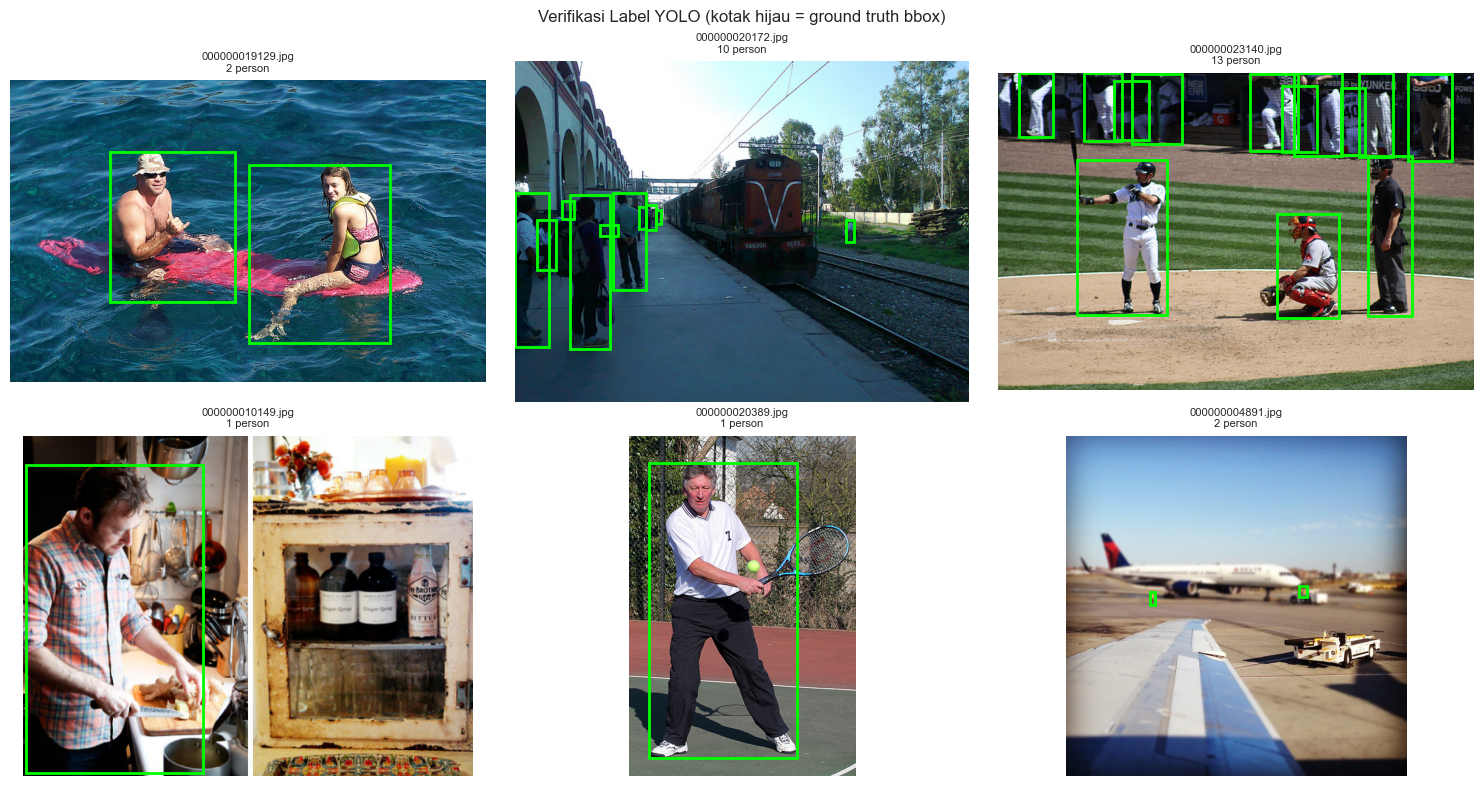

Verifikasi label disimpan ke data/eda_label_verification.png


In [27]:
import random

def draw_yolo_boxes(img_path, label_path):
    img = Image.open(img_path).convert('RGB')
    w, h = img.size
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(img)
    with open(label_path) as f:
        for line in f:
            cls, xc, yc, wn, hn = map(float, line.strip().split())
            x1 = (xc - wn/2) * w
            y1 = (yc - hn/2) * h
            bw = wn * w
            bh = hn * h
            rect = patches.Rectangle((x1, y1), bw, bh,
                                      linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
    ax.set_title(f'{img_path.name}', fontsize=9)
    ax.axis('off')
    return fig

train_imgs  = list((DATASET_DIR / 'images' / 'train').glob('*.jpg'))
sample_imgs = random.sample(train_imgs, min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Verifikasi Label YOLO (kotak hijau = ground truth bbox)', fontsize=12)

for ax, img_path in zip(axes.flat, sample_imgs):
    label_path = DATASET_DIR / 'labels' / 'train' / (img_path.stem + '.txt')
    img = Image.open(img_path).convert('RGB')
    w, h = img.size
    ax.imshow(img)
    if label_path.exists():
        with open(label_path) as f:
            lines = f.readlines()
        for line in lines:
            cls, xc, yc, wn, hn = map(float, line.strip().split())
            x1 = (xc - wn/2) * w
            y1 = (yc - hn/2) * h
            bw = wn * w
            bh = hn * h
            rect = patches.Rectangle((x1, y1), bw, bh,
                                      linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
        ax.set_title(f'{img_path.name}\n{len(lines)} person', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('data/eda_label_verification.png', dpi=100)
plt.show()
print('Verifikasi label disimpan ke data/eda_label_verification.png')


---
## Ringkasan Notebook 02

| Item | Hasil |
|------|-------|
| Anotasi dimuat | COCO JSON (labels.json) |
| Total gambar | 3000 |
| Split | 70% train / 15% val / 15% test |
| Format label | YOLO normalized (class x_c y_c w h) |
| Dataset dir | `dataset/` |

**Langkah selanjutnya** -> `03_training.ipynb`